# Converging the Output Distribution Without a Closed Form: `nlgeom=OFF` vs. `nlgeom=ON`

NB2 built a full Monte Carlo pipeline and sized its sample size, $N=280$, entirely on paper before a single Abaqus job ran. This was possible only because the peak force is an exactly linear map of the input longitudinal strength, $F_{peak}=A\cdot X_T$, and because we chose an analytically defined input distribution. As a consequence, the target relative standard error on the plug-in estimate of the 5th percentile, $\widehat{Q_{5\%}}$, translated directly into a required $N$. NB2 was explicit that this is the exception, not the rule: the moment the input-output map stops being linear — which, for instance, is exactly what `nlgeom=ON` does by introducing the nonlinear element formulation — there is no closed form left, and therefore no formula to size $N$ against.

**This notebook removes that safety net on purpose.** It treats the case with linear element formulation (`nlgeom=OFF`) as if no analytical answer were available, and asks the question a real problem has to answer: *how many samples are enough, and how do we know?* The answer this notebook builds is to monitor a **bootstrap confidence interval** on a distribution-free estimate of $Q_{5\%}$, and keep adding samples until that confidence interval is tight enough. Successively, the notebook repeats the process for the case with nonlinear element formulation (`nlgeom=ON`), where the input-output map is truly nonlinear and no closed form is available at all. The results of the two campaigns are then compared.

**Learning objectives**

- Understand the bootstrap: what resampling *with replacement* from a sample estimates, why it
  works, and how a bootstrap distribution turns into a confidence interval.
- Size the number of bootstrap resamples $B$ empirically, by watching where the reported
  confidence interval stops depending on the random seed, and see that this scatter settles
  onto a floor set by that same discreteness rather than vanishing to zero.
- Define and apply a genuine **convergence criterion** in place of NB2's a-priori sample size:
  stop the first time a bootstrap confidence interval is tight enough — guarded by the smallest
  sample size below which no such interval can exist at all.
- Run two independent, convergence-driven Monte Carlo campaigns (`nlgeom=OFF`, `nlgeom=ON`),
  reusing every one of NB2's existing 280 runs and extending each campaign only as far as its
  own criterion demands.
- Apply NB2's own "look at the data first" pointwise check to `nlgeom=ON`, and use it to catch
  (and understand) a small numerical artifact in the peak-reconstruction method itself.
- Look at each campaign's converged output distribution and summary statistics the way NB2 did,
  and see where `nlgeom=ON` moves the result relative to `nlgeom=OFF`.

Throughout, only the **reconstructed** peak force is used, as already established in NB1 and NB2.


## Part 1 &ndash; The bootstrap

### What a-priori sizing assumed, and what changes without it

NB2's sample-size derivation rested on one fact: for a Normal population, the *standard error*
of an estimator built from $\widehat\mu$ and $\widehat\sigma$ can be written down in closed
form, as a function of $N$ alone. That let NB2 invert the question ("what $N$ hits a 1% target
error?") before running anything.

Take that closed form away and the question does not go away, only the shortcut does. What is needed is some way to ask, *from the sample already in hand*, "how uncertain is my current estimate?", not by assuming a formula, but by
interrogating the data itself.

### The idea

The **bootstrap** ([Efron, 1979](https://doi.org/10.1214/aos/1176344552)) answers exactly that
question. The reasoning starts from a simple observation: the $N$ samples already collected are
themselves the best available stand-in for the population they were drawn from, nothing
else is known about that population except through them. So, instead of repeating the entire
Monte Carlo campaign many times (which would cost $N$ *more* Abaqus runs every time), **resample
from the sample itself**: draw $N$ points **with replacement** from the existing $N$-point
sample, recompute the estimator on that resample, and repeat this resampling $B$ times. The
spread of the resulting $B$ estimates approximates the spread the *real* estimator would have
shown across genuinely independent Monte Carlo campaigns.

**What *with* replacement means.** Resampling *without* replacement from a sample of size $N$,
taking $N$ points, would just reproduce the original sample every time, meaning the estimator
would come out identical on every "resample," telling us nothing about its uncertainty. Sampling
*with* replacement means some points from the existing $N$-point sample can be drawn more than
once and others not at all in any given resample, which is exactly what lets each resample look
like a plausibly different $N$-point sample from the same underlying population.

**Why $B$ is not like $N$.** $N$ is the number of genuine Abaqus runs: each one is new
physical information about $F_{peak}$'s distribution. $B$, the number of *bootstrap* resamples,
is pure computation: every resample reuses the same $N$ underlying points, so no amount of
increasing $B$ can add information the original $N$ samples did not already contain. How large
$B$ actually needs to be is sized later in this Part, once there is a concrete bootstrap distribution to size it against.

**Turning the resampled spread into a confidence interval.** With $B$ bootstrap replicates of an
estimator $\widehat\theta^{(1)},\dots,\widehat\theta^{(B)}$ in hand, the **percentile method**
takes the 2.5th and 97.5th percentiles of that set of replicates as a 95% confidence interval for
the true value of $\theta$.

Everything this notebook needs is imported once, up front: NB2's own KDE functions
(`kde.py`, used below only for the output-distribution plots in Parts 4 and 5) and campaign
machinery (`mc_campaign.py`), imported rather than redefined since NB2 already derived and
explained every one of them, plus the same analytical setup ($\mu$, $\sigma$, the
cross-sectional area $A$) NB2 used throughout, needed below to keep checking Monte Carlo
results against the closed form.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

sys.path.insert(0, "../scripts")
from kde import kde_loo_bandwidth, kde_pdf               # NB2 Part 5's own KDE functions, unchanged
from mc_campaign import load_campaign, run_campaign      # NB2 Part 4's own campaign machinery, plus `nlgeom`
from peak_reconstruction import reconstruct_peak         # NB1's own method, unchanged since NB1 (used in Part 5's artifact figure)

# Same input distribution and cross-sectional area NB2 used throughout, needed below to compute
# the analytical prediction this notebook keeps checking its Monte Carlo results against.
MU, SIGMA, A = 990.0, 49.5, 2.0
Z_5 = float(norm.ppf(0.05))                       # the 5th percentile of the STANDARD normal
analytical_mean, analytical_std = A * MU, A * SIGMA
analytical_q5 = analytical_mean + Z_5 * analytical_std


### The bootstrap, applied to data already in hand

Before writing any new Abaqus-facing machinery, it's worth seeing the bootstrap work on data
NB2 already produced: its 280-run `nlgeom=OFF` campaign, which lives in **`runs/nb02/`**. The cell below reloads that
campaign's reconstructed peak forces and bootstraps $B=1000$ resamples of the order-statistic $Q_{5\%}$. This is a provisional number of resamples for now; Part 1 sizes $B$ properly in a moment.

**What one resample and one replicate actually are.** Each of the $B$ resamples is a fresh draw
of $280$ points, with replacement, from the $280$ reconstructed peak forces on disk. Reading the 5th percentile off *that* resample's own sorted values (its own empirical CDF, in effect) gives one bootstrap replicate of $\widehat{Q}_{5\%}$. Repeating this $B$ times and collecting all $B$ replicates builds up an estimate of the **sampling distribution of the estimator $\widehat{Q}_{5\%}$ itself** and the central 95% of *that* distribution is the confidence interval reported below.

Loaded 280 completed runs from NB2's own campaign.


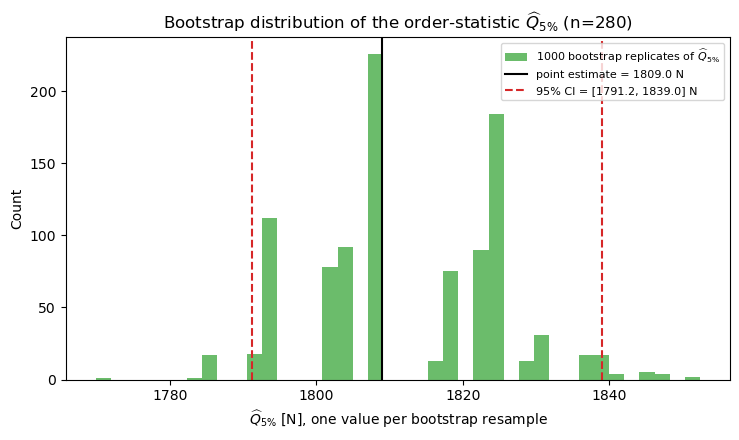

Point estimate:        1809.03 N
95% bootstrap CI:      [1791.15, 1839.01] N
Half-width:            23.93 N  (1.32% of the estimate)


In [2]:
# Load NB2's own 280-run campaign straight from ITS OWN results folder -- not a copy under this
# notebook's runs/nb03/ -- so this demonstration genuinely uses "data already in hand," not a
# duplicate of it.
nlgeom_off_nb2 = load_campaign("../runs/nb02/summary.csv")
f_peak_nb2 = nlgeom_off_nb2["f_peak_recon"]
N_NB2 = len(f_peak_nb2)
print(f"Loaded {N_NB2} completed runs from NB2's own campaign.")

# Set up a random number generator for reproducibility, and define the number of bootstrap resamples to draw.
rng_demo = np.random.default_rng(42)
B_DEMO = 1000

# The resampling step itself: B_DEMO x N_NB2 indices, each drawn uniformly from {0,...,N_NB2-1},
# WITH replacement -- rng.integers's default behaviour is exactly "with replacement" (it does not
# remove a value from consideration once drawn), which is what makes each row of `idx` a
# genuinely fresh 280-point draw rather than a reshuffling of the same 280 values.
idx = rng_demo.integers(0, N_NB2, size=(B_DEMO, N_NB2))
resamples = f_peak_nb2[idx]                             # shape (B_DEMO, N_NB2): one resample per row

# One bootstrap replicate per resample: the 5th percentile read off THAT row's own sorted values
# (numpy's default "linear" interpolation between the two order statistics bracketing the 5%
# level -- the same convention NB2 used for its own order-statistic estimator).
replicates_os = np.percentile(resamples, 5, axis=1)

# The point estimate itself is the 5th percentile of the ORIGINAL 280-point sample (not of the
# replicates -- the replicates describe the estimator's uncertainty, not a better point estimate
# of it).
estimate_os = float(np.percentile(f_peak_nb2, 5))

# The percentile method: the central 95% of the B_DEMO replicates IS the 95% confidence interval.
ci_lo_os, ci_hi_os = np.percentile(replicates_os, [2.5, 97.5])
half_width_os = 0.5 * (ci_hi_os - ci_lo_os)
rel_half_width_os = half_width_os / abs(estimate_os)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(replicates_os, bins=40, color="C2", alpha=0.7,
        label=f"{B_DEMO} bootstrap replicates of $\\widehat{{Q}}_{{5\\%}}$")
ax.axvline(estimate_os, color="k", lw=1.5, label=f"point estimate = {estimate_os:.1f} N")
ax.axvline(ci_lo_os, color="C3", ls="--", lw=1.5,
           label=f"95% CI = [{ci_lo_os:.1f}, {ci_hi_os:.1f}] N")
ax.axvline(ci_hi_os, color="C3", ls="--", lw=1.5)
ax.set_xlabel("$\\widehat{Q}_{5\\%}$ [N], one value per bootstrap resample")
ax.set_ylabel("Count")
ax.set_title(f"Bootstrap distribution of the order-statistic $\\widehat{{Q}}_{{5\\%}}$ (n={N_NB2})")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"Point estimate:        {estimate_os:.2f} N")
print(f"95% bootstrap CI:      [{ci_lo_os:.2f}, {ci_hi_os:.2f}] N")
print(f"Half-width:            {half_width_os:.2f} N  ({100 * rel_half_width_os:.2f}% of the estimate)")

The gaps in the histogram are real, and they are a symptom of the fact that the 5-th percentile of the bootstrap distribution of $F_{peak}$ can only ever take as many distinct values as there are ways to interpolate between a handful of original data points.

At $n=280$, `np.percentile(..., 5)` applied to each bootstrap resample reads the 5th percentile
off rank $0.05\times(280-1)=13.95$ — 95% of the way from the 14th smallest value to the 15th,
i.e. $0.05\,x_{(14)} + 0.95\,x_{(15)}$. A bootstrap resample can only ever contain values that
were **already in the original 280-point sample**, so whichever two of the original points end
up at ranks 14 and 15 *within that resample*, the replicate is that same 5%/95% blend of
*some* pair from the original sample's own lower tail. In other words, a small, finite set of achievable
values, not a continuum. With only that handful of points to draw pairs from, 1000 replicates
cannot help but pile up on a coarse lattice, leaving the gaps in the histogram above. The cell
below makes this concrete: it prints the sorted sample around the 5% level, verifies every
replicate really does land on that lattice, and counts how many *distinct* values it actually
takes.


Smallest 16 of the 280 original samples (the values a resample's own order statistics can
draw from near the 5th percentile):
[1738.29 1739.04 1754.13 1769.94 1778.8  1784.59 1785.01 1785.13 1791.47
 1794.03 1794.62 1802.74 1804.14 1808.79 1809.04 1817.8 ]

Of the 1000 bootstrap replicates computed above, only 94 distinct values appear.
Replicates lying exactly on the 0.05*x_(i) + 0.95*x_(j) lattice (i, j among the 40 smallest original values): 1000 of 1000.
Point estimate 1809.03 N falls in the bin with the MOST replicates (226 of 1000), flanked by empty bins on both sides (20 of the 40 bins are empty) -- a spike, not a gap, at the one value the original sample's own rank pair produces.


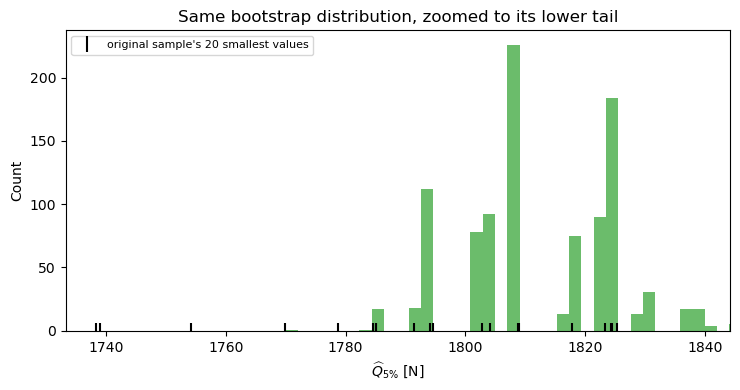

In [3]:
# The order statistics that can ever appear in a resample's own 5th-percentile calculation are
# drawn from the original sample's lower tail -- print the dozen or so smallest values so the
# lattice the replicates above are piling up on is visible directly, not just asserted.
f_sorted = np.sort(f_peak_nb2)
print("Smallest 16 of the 280 original samples (the values a resample's own order statistics can")
print("draw from near the 5th percentile):")
print(np.round(f_sorted[:16], 2))

n_unique = len(np.unique(np.round(replicates_os, 6)))
print(f"\nOf the {B_DEMO} bootstrap replicates computed above, only {n_unique} distinct values "
      f"appear.")

# Verify the lattice explanation directly, rather than asserting it: every one of the 1000
# replicates above should be EXACTLY 0.05*(one of the original sample's lower-tail values) +
# 0.95*(another one) -- the same two interpolation weights `np.percentile` itself uses at rank
# 0.05*(280-1)=13.95, just applied to whichever pair of original points happens to land at
# ranks 14 and 15 within that particular resample.
lattice = np.unique(np.round(0.05 * f_sorted[:40, None] + 0.95 * f_sorted[None, :40], 6))
on_lattice = np.isin(np.round(replicates_os, 6), lattice)
print(f"Replicates lying exactly on the 0.05*x_(i) + 0.95*x_(j) lattice "
      f"(i, j among the 40 smallest original values): {on_lattice.sum()} of {B_DEMO}.")

# The point estimate itself is one particular point on that same lattice -- the pair the
# ORIGINAL sample's own ranks 14 and 15 produce -- so it should sit in the tallest bin, not a
# gap, once the histogram below is drawn finely enough to see it.
counts, edges = np.histogram(replicates_os, bins=40)
est_bin = int(np.digitize(estimate_os, edges) - 1)
print(f"Point estimate {estimate_os:.2f} N falls in the bin with the MOST replicates "
      f"({counts[est_bin]} of {B_DEMO}), flanked by empty bins on both sides "
      f"({int((counts == 0).sum())} of the 40 bins are empty) -- a spike, not a gap, at the one "
      f"value the original sample's own rank pair produces.")

# Re-draw the same histogram, this time with the original sample's own lower-tail values marked
# as a rug underneath -- every gap in the bars should line up with a gap between two neighbouring
# rug marks, confirming the lattice explanation rather than just asserting it.
fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.hist(replicates_os, bins=40, color="C2", alpha=0.7)
ax.plot(f_sorted[:20], np.zeros(20), "|", color="k", ms=12, mew=1.5,
        label="original sample's 20 smallest values")
ax.set_xlim(f_sorted[0] - 5, np.percentile(replicates_os, 99))
ax.set_xlabel("$\widehat{Q}_{5\%}$ [N]")
ax.set_ylabel("Count")
ax.set_title("Same bootstrap distribution, zoomed to its lower tail")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


Every one of the $B$ replicates is `np.percentile` applied to a 280-point *resample*, and a resample can only ever
contain values already in the original 280-point sample. So every replicate has to land on the
finite set of values that some pair of original points produces by the same linear
interpolation `np.percentile` itself uses, and there is no way to draw a resample whose 5th
percentile falls anywhere else. Discreteness here is not a symptom of a bad estimator; it is a
**guaranteed consequence of resampling with replacement from a finite sample**, and it would
appear for any finite $n$, just with fewer, sparser achievable values as $n$ shrinks.

[Hall & Martin (1989)](https://doi.org/10.1016/0167-7152(89)90121-1) showed that the
percentile-method bootstrap confidence interval for a quantile is, exactly, the classical
distribution-free confidence interval built directly from the sample's own order statistics. The two are the same interval, arrived at two different ways. So the lattice above is the same finite-sample mechanism that interval has always had; the bootstrap did not introduce it, it
only made it visible as a histogram.

**Nothing here needs fixing.** This notebook proceeds with the order-statistic estimator, used
for both the point estimate above and the confidence interval built from it.

*(A smoothed, KDE-based percentile is the right tool when $N$ is genuinely small, such as in [Catalanotti (2022)](https://doi.org/10.1016/j.compositesa.2022.107238), where a 1st-percentile is estimated from just $N=10$ coupons, and where the interpolation lattice is coarse enough to matter and some smoothing buys real precision at the cost of a bias that then has to be tracked. At the few-hundred-sample sizes this notebook reaches, that trade is not worth making, so it is deferred to a later notebook.)*

### The half-width, and why the half-width

Every bootstrap result above has been summarized by one number, the **half-width**:

$$h_{\mathrm{CI}} = \tfrac12\left(\widehat{Q}^{(97.5)} - \widehat{Q}^{(2.5)}\right), \qquad
h_{\mathrm{rel}} = \frac{h_{\mathrm{CI}}}{\left|\widehat{Q}_{5\%}\right|}$$

where $\widehat{Q}^{(2.5)}$ and $\widehat{Q}^{(97.5)}$ are the 2.5th and 97.5th percentiles of the
bootstrap replicates, the two ends of the confidence interval. $h_{\mathrm{CI}}$ is simply
the "$\pm$" in $\widehat{Q}_{5\%}\pm h_{\mathrm{CI}}$: it is the direct, distribution-free
analogue of NB2's own target, which was written as $k\cdot\mathrm{relSE}\le1\%$ with $k=2$, i.e. a $\pm2\,\mathrm{SE}$ band, a half-width in exactly the same sense, just built from a formula instead of from resampling.

One subtlety: the bootstrap interval is not generally symmetric about the point estimate (the
cell below prints both arms explicitly for the order-statistic result above). Our
$h_{\mathrm{CI}}$ is the *average* of the two arms, one number that we will use to write a
convergence criterion.


In [4]:
# The two bootstrap arms are NOT symmetric about the point estimate (Part 1's own point above):
# print them separately here, then the half-width that averages them, so the asymmetry is
# visible directly in the numbers rather than only asserted in the text.
lower_arm = estimate_os - ci_lo_os
upper_arm = ci_hi_os - estimate_os
print(f"Point estimate:              {estimate_os:.2f} N")
print(f"Lower arm (est. - CI low):   {lower_arm:.2f} N")
print(f"Upper arm (CI high - est.):  {upper_arm:.2f} N")
print(f"Half-width (their average):  {half_width_os:.2f} N")
print(f"Relative half-width:         {100 * rel_half_width_os:.2f}%  "
      f"(this is the number a convergence criterion is written against)")


Point estimate:              1809.03 N
Lower arm (est. - CI low):   17.88 N
Upper arm (CI high - est.):  29.98 N
Half-width (their average):  23.93 N
Relative half-width:         1.32%  (this is the number a convergence criterion is written against)


### How many resamples? Sizing $B$

$B$ was used above without justification, so it's time to size it properly. $B$ is pure
computation: it adds no information the $N$ Abaqus runs did not already contain (Part 1 already
established that). So the only question is a practical one: **how large does $B$ have to be
before the numbers we care about stop depending on it?**

Notice first that the *point estimate* does not depend on $B$ at all, as it is computed from
the original 280-point sample, once, regardless of how many bootstrap resamples follow. What
*does* depend on $B$ is the **reported half-width**, which is exactly the number this notebook's
stopping rule will be written against. And because every bootstrap run draws its own random
resamples, "does the half-width depend on $B$" is really the question "would a *different random
seed* give a different half-width at this $B$?"

That is directly measurable: run the whole bootstrap several times at a range of $B$, each time
with an independent seed, and watch how much the reported half-width itself moves around. The
cell below first collects the demo's own resampling-and-percentile steps into one reusable
function, `bootstrap_ci` — needed now because sizing $B$ means running that procedure hundreds
of times, not because anything about the method itself has changed — then, for each $B$ from 50
to 5000, repeats the bootstrap 30 times with independent seeds and plots every single one of
those 30 relative half-widths as its own point.


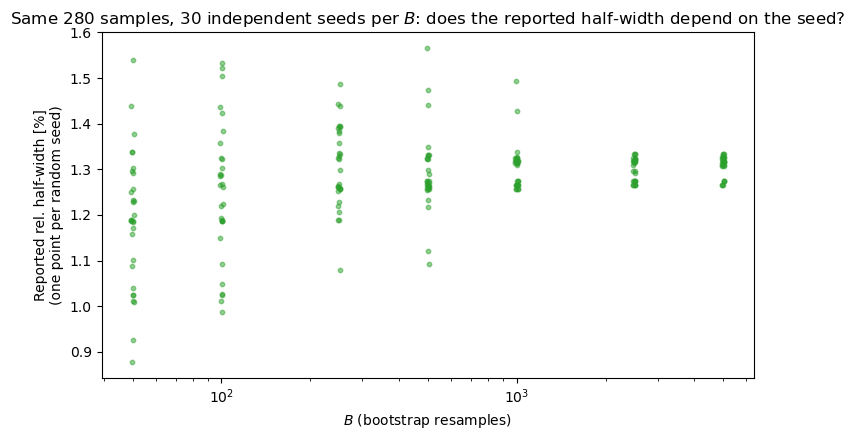

In [5]:
def bootstrap_ci(x, statfunc, n_boot=1000, rng=None):
    '''Percentile-method bootstrap CI for any statistic. `statfunc(a, axis)` must compute the
    statistic ALONG `axis` -- np.mean and np.percentile both do this already, which is what
    lets every one of the n_boot replicates be computed in a single vectorised call instead of
    a Python loop over resamples.

    The point estimate is `statfunc` applied to the ORIGINAL sample; the replicates describe
    its bootstrap uncertainty (Part 1's own distinction, made explicit again here since this
    one function is what every later section in this notebook calls).
    '''
    x = np.asarray(x, dtype=float)
    n = len(x)
    estimate = float(statfunc(x, axis=0))
    if rng is None:
        rng = np.random.default_rng()
    idx = rng.integers(0, n, size=(n_boot, n))     # WITH replacement, same as the demo above
    replicates = statfunc(x[idx], axis=1)          # one replicate per resample, all n_boot rows at once
    ci_lo, ci_hi = np.percentile(replicates, [2.5, 97.5])
    half_width = 0.5 * (ci_hi - ci_lo)
    return {
        "n": n, "estimate": estimate, "ci_low": float(ci_lo), "ci_high": float(ci_hi),
        "half_width": float(half_width), "rel_half_width": float(half_width / abs(estimate)),
        "replicates": replicates,
    }


q5_fn = lambda a, axis: np.percentile(a, 5, axis=axis)   # the 5th percentile, read as an order statistic

B_GRID = [50, 100, 250, 500, 1000, 2500, 5000]
N_SEEDS = 30           # independent repeats per B, to see how much one bootstrap run at that B
                       # would itself vary from another, purely from its own random draws

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for B in B_GRID:
    # Repeat the SAME bootstrap N_SEEDS times at this B, changing only the random seed feeding
    # the resampling: if the reported half-width depends mainly on B (and only a little on the
    # seed), the N_SEEDS points at this B will be tightly clustered; if B is too small, they
    # will be spread out.
    vals = np.array([
        bootstrap_ci(f_peak_nb2, q5_fn, n_boot=B, rng=np.random.default_rng(3000 + s))["rel_half_width"]
        for s in range(N_SEEDS)
    ])
    # Every one of the N_SEEDS repeats plotted as its own point at this B, with a small random
    # horizontal jitter so all 30 points at the same B are visible rather than overlapping.
    jitter = B * (0.02 * (np.random.default_rng(0).random(N_SEEDS) - 0.5))
    ax.scatter(np.full(N_SEEDS, B) + jitter, 100 * vals, s=10, alpha=0.5, color="C2")

ax.set_xscale("log")  # B spans two orders of magnitude (50 to 5000), so a log axis keeps every group readable
ax.set_xlabel("$B$ (bootstrap resamples)")
ax.set_ylabel("Reported rel. half-width [%]\n(one point per random seed)")
ax.set_title("Same 280 samples, 30 independent seeds per $B$: does the reported half-width depend on the seed?")
fig.tight_layout()
plt.show()


**Read the plot from left to right.** At small $B$, the 30 points at each $B$ are spread
over a wide vertical band: the same 280 samples, bootstrapped with a different random seed, give
visibly different answers. At $B=50$ the reported half-width ranges from 0.88% to 1.54%
(a spread of 0.66 percentage points), sizeable next to a criterion that will be written at the
1% level. As $B$ grows the cloud narrows — unevenly at first (30 seeds is itself a small sample
of the scatter, so the spread does not shrink perfectly monotonically batch to batch) — then
decisively: by $B=1000$ the 30 seeds agree to within about 0.24 percentage points
(1.26%–1.49%), and by $B=2500$ the spread has fallen to about 0.07 points and does **not**
shrink further even at $B=5000$. That floor is the same discreteness from the section above: with only a few dozen achievable replicate values near the 5% level, no amount of resampling can make the reported percentiles of *that* finite set any more precise
than the gaps between them allow. (The number of *distinct* replicate values does keep climbing
with $B$, from about 30 at $B=50$ to over 100 at $B=5000$, but the CI's own endpoints,
themselves percentiles of a finite replicate set, stop moving well before the replicate count
does.)

**Adopt $B=1000$.** Past this point more resampling buys very little against the 1% target this
notebook is about to set, and it is also exactly what [Catalanotti (2022)](https://doi.org/10.1016/j.compositesa.2022.107238) uses, so the measurement above and the methodological source this notebook follows agree, rather than the notebook
picking a large-sounding round number of its own.

## Part 2 &ndash; Choosing a convergence criterion

**Stop adding samples once the bootstrap 95% confidence interval on the order-statistic
$\widehat{Q}_{5\%}$ has a relative half-width $\le 1\%$, checked every 10 new samples, and never before $n=60$.**

- The interval is **computable from the sample in hand** and says how far the current estimate
  plausibly is from the truth. For instance, this is different from watching whether the running estimate has
  "stopped moving," which only measures the estimator's own inertia, not its distance from the truth.
- The **1% target** matches NB2's own target on the plug-in estimator, so the extra cost of a
  distribution-free approach &mdash; more samples needed for the same nominal precision &mdash;
  is itself something this notebook's results make visible.
- **A minimum sample size, $n_{\min}$.** No check is allowed to pass before $n_{\min}$, because
  below a certain $N$ a 95% distribution-free interval on a *5th* percentile cannot exist at
  all, regardless of how tight the bootstrap makes it look. An order-statistic interval for
  $Q_p$ is bounded by the sample's own extremes, $[x_{(1)}, x_{(N)}]$; that widest possible
  interval still fails to cover $Q_p$ whenever every one of the $N$ points happens to land on
  the same side of it, which happens with probability $p^N + (1-p)^N$ (all above, or all
  below). A 95% interval can only exist once that failure probability is itself below
  $\alpha=0.05$:
  $$p^N + (1-p)^N \le \alpha \quad\Longrightarrow\quad N \ge \frac{\ln\alpha}{\ln(1-p)}
  \quad\text{(the $p^N$ term is negligible for small $p$)}$$
  At $p=\alpha=0.05$ this gives $N \ge 58.4$, i.e. $N\ge59$; rounded up to this notebook's own
  10-sample check grid, **$n_{\min}=60$**.
- Checks happen once per **batch of 10 new samples**: frequent enough to pin down the
  actual stopping point to within 10 samples, at a cost (a few milliseconds of resampling per
  check) that is negligible next to a single Abaqus run (~20 s, see below).


Before building the campaign machinery, it is worth applying this exact criterion to the one
sample already fully in hand: NB2's own $N=280$ `nlgeom=OFF` campaign. The cell below bootstraps
its order-statistic percentile the same way as above.


In [6]:
# Apply Part 2's own criterion to NB2's already-completed N=280 campaign, using the same seed
# (101) the checker below will reuse for Campaign A's own first check -- so this number is
# directly comparable to that first check in Part 4, not just to the criterion in the abstract.
boot_nb2 = bootstrap_ci(f_peak_nb2, q5_fn, n_boot=1000, rng=np.random.default_rng(101))

print(f"NB2's own N={N_NB2} campaign, checked against THIS notebook's own criterion:")
print(f"  rel. half-width: {100 * boot_nb2['rel_half_width']:.3f}%  "
      f"({'PASSES' if boot_nb2['rel_half_width'] <= 0.01 else 'still above'} the 1% target)")


NB2's own N=280 campaign, checked against THIS notebook's own criterion:
  rel. half-width: 1.265%  (still above the 1% target)


**NB2's 280 samples do not pass this notebook's own criterion.** At $B=1000$ the
order-statistic relative half-width comes out at 1.265%, above the 1% target, meaning that the plain order statistic needs more
than 280 samples to reach the 1% target.

Both campaigns below have to be run out further than NB2's own $N=280$, and checked in full
against this criterion batch by batch, before either counts as converged.


### `ConvergenceChecker`: the criterion, as reusable state

`check(sample)` needs to remember two things across repeated calls as the campaign grows: every
bootstrap result computed so far (so the convergence plots in Parts 4 and 5 can show the whole
trajectory, not just the last point) and its own random generator (so each call draws a fresh,
independent set of resamples rather than repeating the same one). The class below wraps exactly
that state.


In [7]:
class ConvergenceChecker:
    '''Stateful convergence criterion for an open-ended Monte Carlo campaign: keep adding
    samples, bootstrapping a fresh confidence interval on the order-statistic Q5% after every
    batch, until that interval's relative half-width drops to (or below) the 1% target for the
    FIRST time. `n_min` is not this class's job to enforce -- Part 2's existence condition means
    no check below n_min could ever pass anyway, so `run_until_converged` (below) simply never
    calls `check` before then.

    Call `check(sample)` once per batch, with every reconstructed peak completed so far.
    '''

    def __init__(self, label, p=0.05, target_rel_half_width=0.01, n_boot=1000, rng=None):
        self.label = label                              # a short tag, printed with every check, so OFF's and ON's logs are easy to tell apart
        self.p = p                                       # which percentile to track (0.05 -> Q5%)
        self.target_rel_half_width = target_rel_half_width  # the 1% stopping target
        self.n_boot = n_boot                             # bootstrap resamples per check (B, sized in Part 1)
        # A dedicated random generator for THIS checker's own bootstrap draws, kept separate
        # from whatever generator drew the X_T samples themselves, so the two streams of
        # randomness cannot interfere with each other, and re-used (not re-seeded) across
        # calls so consecutive checks draw fresh, independent resamples.
        self.rng = rng if rng is not None else np.random.default_rng()
        self.history = []        # one bootstrap result dict per check() call, for later plotting

    def check(self, sample):
        # A run whose peak failed to reconstruct contributes NaN to `sample`; drop it before
        # bootstrapping, since np.percentile has no sensible answer for a NaN-contaminated row.
        sample = np.asarray(sample, dtype=float)
        sample = sample[~np.isnan(sample)]

        # The statistic being bootstrapped: the p-th percentile, read directly off the sample
        # (or off each resample) as an order statistic -- no smoothing, see Part 1.
        q5_fn = lambda a, axis: np.percentile(a, 100 * self.p, axis=axis)
        result = bootstrap_ci(sample, q5_fn, n_boot=self.n_boot, rng=self.rng)
        self.history.append(result)   # keep every check, so the convergence plots can show the whole trajectory

        passed = result["rel_half_width"] <= self.target_rel_half_width
        print(f"[{self.label}] n={result['n']:4d}  "
              f"Q{100 * self.p:.0f}%_hat={result['estimate']:8.2f} N  "
              f"95% CI=[{result['ci_low']:8.2f}, {result['ci_high']:8.2f}]  "
              f"rel_half_width={100 * result['rel_half_width']:.3f}%  "
              f"({'CONVERGED' if passed else 'not yet'})")
        return passed


**Reading `ConvergenceChecker`.** `__init__` stores the target (1% relative half-width), the
number of bootstrap resamples, and its own random generator. `check(sample)` is called once per
batch: it bootstraps a fresh confidence interval on the *current* sample via `bootstrap_ci`
(defined in Part 1), records it in `self.history`, and returns `True` the first time
`rel_half_width <= target_rel_half_width`. This is the `stop_check` callback the campaign driver
below calls after every batch.


### The campaign driver: running batches until `stop_check` says stop

`run_campaign` (imported from `mc_campaign`, NB2's own resumable, per-sample logic) runs a
*fixed* list of samples in one call. What is new here is only the outer loop: call it with a
successively longer prefix of the same input pool, so each call runs exactly one new batch of
10 samples (`run_campaign` skips every sample already recorded, so handing it a longer prefix
each time is what makes this "run 10 more" rather than "start over"), and ask
`ConvergenceChecker.check` after every batch whether to stop.

In [8]:
def run_until_converged(x_pool, nlgeom, runs_dir, summary_csv, target_u1, stop_check,
                        n_min, batch_size=10):
    '''Grow the campaign in batches of `batch_size` new samples (drawn in order from `x_pool`)
    until `stop_check(f_peak_recon_array)` returns True. Resumable exactly like `run_campaign`
    itself: a sample already recorded in summary_csv is skipped, so interrupting this and
    calling it again later continues from wherever it left off, and running it again after
    everything needed is already on disk launches NO new Abaqus jobs at all.
    '''
    # Start the loop AT n_min, not at batch_size: Part 2 showed no 95% distribution-free
    # interval on Q5% can exist below n_min samples, so checking any earlier batch would only
    # spend bootstrap computation on a check that is guaranteed to fail.
    for n in range(n_min, len(x_pool) + 1, batch_size):
        # Handing run_campaign a LONGER prefix of the same pool each time runs exactly the
        # batch_size new samples this iteration needs -- everything shorter is already recorded
        # and skipped.
        run_campaign(x_pool[:n], runs_dir, summary_csv, target_u1, nlgeom=nlgeom, verbose=False)

        f = load_campaign(summary_csv, n_max=n)["f_peak_recon"]
        f = f[~np.isnan(f)]              # a run whose peak failed to reconstruct contributes NaN
        converged = stop_check(f)
        print(f"[nlgeom={nlgeom}] n={n:4d}  (batch just completed) -> "
              f"{'CONVERGED' if converged else 'not yet converged'}")
        if converged:
            return n
    raise RuntimeError(f"x_pool exhausted at n={len(x_pool)} without converging.")


## Part 3 &ndash; Reusing NB2's draw

Both campaigns below extend the *identical* $X_T\sim\mathcal N(990,\,49.5)$, seed-2 draw NB2
used, generated once as a pool of `N_MAX=2000` values, large enough that neither
campaign's convergence criterion is ever expected to need most of it. Because `numpy`'s
`default_rng` produces a deterministic stream, the first 280 values of a 2000-value draw are
*exactly* the first 280 values of a 280-value draw from the same seed: the cell below asserts
this directly, for `nlgeom=OFF` against NB2's own `runs/nb02/summary.csv` (its real campaign, as
in Part 1) and for `nlgeom=ON` against this notebook's own CSV (which has no NB2 predecessor), so
both of this notebook's campaigns are a genuine continuation of that same draw, not a
coincidentally similar one.

In [9]:
SEED = 2  # random seed for the X_T pool, so every campaign below draws from the same 2000 samples
TARGET_U1 = 4.0  # NB2's own displacement budget (Part 3) -- unchanged by nlgeom, see NB2
N_MAX = 2000  # maximum number of samples in the X_T pool
N_MIN = 60  # Part 2's own existence bound: no check is run below this many samples

# The pool of X_T samples is drawn ONCE, and then every campaign below draws from the same
x_pool = np.random.default_rng(SEED).normal(MU, SIGMA, N_MAX)

# nlgeom=OFF's own 280-sample prefix has its real home in runs/nb02/summary.csv (Part 1); the ON
# campaign has no NB2 predecessor, so it is checked against its own (this notebook's) CSV.
assert np.allclose(nlgeom_off_nb2["x_t"], x_pool[:N_NB2]), \
    "nlgeom=OFF: NB2's own X_T draw does not match this notebook's pool -- seed mismatch?"
print(f"nlgeom=OFF: first {N_NB2} pool values match NB2's own campaign draw exactly.")

# Iterate over both nlgeom settings, checking whether a campaign already exists on disk and if so
# verifying that its X_T draw matches the pool this notebook drew. If it does not exist, the
# campaign is run from scratch until it converges according to the criterion above.
for nlgeom in ("off", "on"):
    summary_csv = f"../runs/nb03/monte_carlo_summary_{nlgeom}.csv"
    if not Path(summary_csv).exists():
        continue
    existing = load_campaign(summary_csv, n_max=N_NB2)
    assert np.allclose(existing["x_t"], x_pool[:N_NB2]), \
        f"nlgeom={nlgeom}: existing campaign's X_T draw does not match this notebook's pool -- seed mismatch?"
    print(f"nlgeom={nlgeom.upper()}: first {N_NB2} pool values match its own on-disk campaign exactly.")


nlgeom=OFF: first 280 pool values match NB2's own campaign draw exactly.
nlgeom=OFF: first 280 pool values match its own on-disk campaign exactly.
nlgeom=ON: first 280 pool values match its own on-disk campaign exactly.


Both assertions pass: the first 280 values of this notebook's own pool are byte-for-byte
the same draw NB2 used, and the same draw already on disk under both of this notebook's own
campaign CSVs. Everything below is a genuine continuation of that one draw, not a fresh,
coincidentally similar one.

## Part 4 &ndash; Campaign A: `nlgeom=OFF`, converged as if no closed form existed

This campaign already has 280 completed runs from NB2. The cell below builds a fresh `ConvergenceChecker` and hands it to `run_until_converged`, which checks convergence after every batch of 10 and stops the moment the criterion is met.

In [10]:
RUNS_DIR_OFF = Path("../runs/nb03/mc_runs_nlgeom_off")
SUMMARY_CSV_OFF = Path("../runs/nb03/monte_carlo_summary_off.csv")

# A dedicated ConvergenceChecker for this campaign, with its own seeded random generator so its
# bootstrap draws are reproducible and independent of the ON campaign's own checker in Part 5.
checker_off = ConvergenceChecker(
    "nlgeom=OFF", p=0.05, target_rel_half_width=0.01, n_boot=1000,
    rng=np.random.default_rng(101),
)

# The actual work: grow the campaign 10 samples at a time, bootstrapping a fresh check after
# every batch, until checker_off.check reports the 1% target has been reached.
N_OFF = run_until_converged(
    x_pool=x_pool,
    nlgeom="OFF",
    runs_dir=RUNS_DIR_OFF,
    summary_csv=SUMMARY_CSV_OFF,
    target_u1=TARGET_U1,
    stop_check=checker_off.check,
    n_min=N_MIN,
    batch_size=10,
)

print(f"\nnlgeom=OFF converged at N={N_OFF}.")


[nlgeom=OFF] n=  60  Q5%_hat= 1817.35 N  95% CI=[ 1791.80,  1879.26]  rel_half_width=2.406%  (not yet)
[nlgeom=OFF] n=  60  (batch just completed) -> not yet converged


[nlgeom=OFF] n=  70  Q5%_hat= 1812.84 N  95% CI=[ 1739.04,  1870.32]  rel_half_width=3.621%  (not yet)
[nlgeom=OFF] n=  70  (batch just completed) -> not yet converged
[nlgeom=OFF] n=  80  Q5%_hat= 1817.35 N  95% CI=[ 1739.04,  1867.46]  rel_half_width=3.533%  (not yet)
[nlgeom=OFF] n=  80  (batch just completed) -> not yet converged
[nlgeom=OFF] n=  90  Q5%_hat= 1822.63 N  95% CI=[ 1770.43,  1870.32]  rel_half_width=2.740%  (not yet)
[nlgeom=OFF] n=  90  (batch just completed) -> not yet converged
[nlgeom=OFF] n= 100  Q5%_hat= 1828.01 N  95% CI=[ 1791.84,  1874.28]  rel_half_width=2.255%  (not yet)
[nlgeom=OFF] n= 100  (batch just completed) -> not yet converged
[nlgeom=OFF] n= 110  Q5%_hat= 1826.35 N  95% CI=[ 1794.62,  1871.78]  rel_half_width=2.112%  (not yet)
[nlgeom=OFF] n= 110  (batch just completed) -> not yet converged
[nlgeom=OFF] n= 120  Q5%_hat= 1824.23 N  95% CI=[ 1785.13,  1873.09]  rel_half_width=2.411%  (not yet)
[nlgeom=OFF] n= 120  (batch just completed) -> not yet co

The relative half-width does not fall monotonically. In the batches leading up to
convergence it sits just above the 1% line three times in a row &ndash; 1.039% at $n=340$,
1.008% at $n=350$, and 1.022% at $n=360$ &ndash; before finally dropping to 0.993% at $n=370$.
The point estimate itself barely moves across that whole stretch (1807.72 N to 1805.83 N, about
0.1%), so what decides *when* the campaign stops is essentially which side of 1% the bootstrap
happens to land on for a given batch, not a meaningful change in the estimate.


### Watching it converge

The cell below turns `checker_off.history` &mdash; one bootstrap result per batch checked,
already recorded during the run above &mdash; into two plots: how $\widehat{Q_{5\%}}$ and its
95% band evolved as $n$ grew, and how the relative half-width itself shrank toward (and through)
the 1% target.


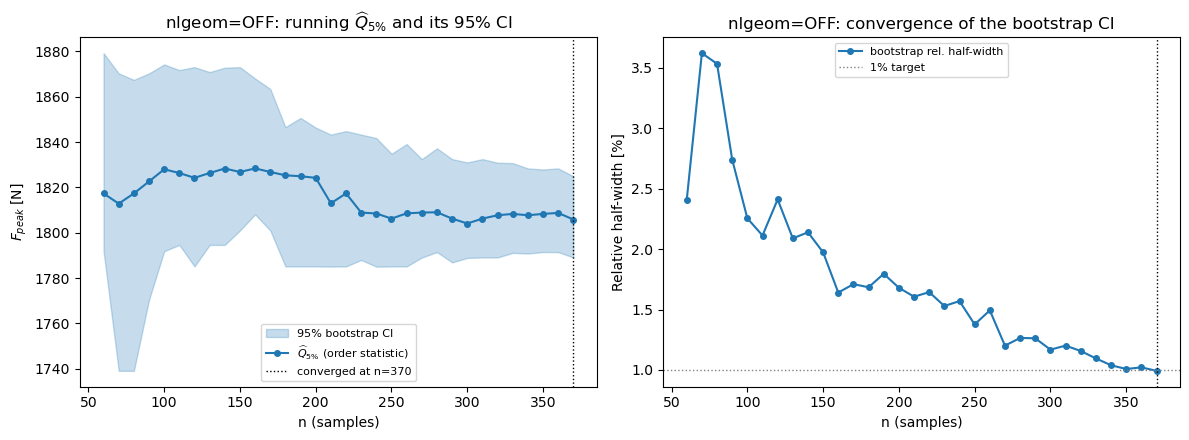

In [11]:
def plot_convergence(checker, color, title):
    # Unpack the whole trajectory from checker.history: one dict per batch checked, in the order
    # the checks were made, so a simple list comprehension recovers the n / estimate / CI /
    # half-width sequence both panels below need.
    ns = np.array([h["n"] for h in checker.history])
    est = np.array([h["estimate"] for h in checker.history])
    lo = np.array([h["ci_low"] for h in checker.history])
    hi = np.array([h["ci_high"] for h in checker.history])
    rel_hw = np.array([h["rel_half_width"] for h in checker.history])
    n_final = ns[-1]   # the batch on which the criterion first passed

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # Left panel: the running point estimate and its 95% bootstrap band, so both how Q5% itself
    # evolves and how much the band around it narrows as n grows are visible together.
    axes[0].fill_between(ns, lo, hi, color=color, alpha=0.25, label="95% bootstrap CI")
    axes[0].plot(ns, est, "o-", color=color, ms=4, label=r"$\widehat{Q}_{5\%}$ (order statistic)")
    axes[0].axvline(n_final, color="k", ls=":", lw=1, label=f"converged at n={n_final}")
    axes[0].set_xlabel("n (samples)")
    axes[0].set_ylabel("$F_{peak}$ [N]")
    axes[0].set_title(f"{title}: running $\widehat{{Q}}_{{5\%}}$ and its 95% CI")
    axes[0].legend(fontsize=8)

    # Right panel: the relative half-width itself, the one number the stopping rule is actually
    # written against, together with the 1% line it has to cross.
    axes[1].plot(ns, 100 * rel_hw, "o-", color=color, ms=4, label="bootstrap rel. half-width")
    axes[1].axhline(1.0, color="gray", ls=":", lw=1, label="1% target")
    axes[1].axvline(n_final, color="k", ls=":", lw=1)
    axes[1].set_xlabel("n (samples)")
    axes[1].set_ylabel("Relative half-width [%]")
    axes[1].set_title(f"{title}: convergence of the bootstrap CI")
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    plt.show()


plot_convergence(checker_off, "C0", "nlgeom=OFF")


Both panels tell the same story visually: the left panel shows $\widehat{Q}_{5\%}$ settling
toward its final value from around $n=250$ onward, with the 95% band visibly narrowing as $n$
grows; the right panel shows the relative half-width approaching the 1% line from above and
finally crossing it for good at the point marked by the dotted vertical line.


### Campaign cost

Before looking at the converged distribution itself, the cell below reports this campaign's
total cost, straight from `summary.csv`'s own `run_seconds` column &ndash; the sum of every
individual run's own solve time (NB2 Part 4's own reporting).

In [12]:
# Every completed run's own solve time is already recorded in summary.csv (NB2 Part 4's own
# reporting); summing it directly gives this campaign's real Abaqus wall-clock cost, no need to
# re-time anything.
run_seconds_off = load_campaign(SUMMARY_CSV_OFF, n_max=N_OFF)["run_seconds"]
print(f"--- nlgeom=OFF campaign cost ({len(run_seconds_off)} completed runs) ---")
print(f"Total wall-clock time (sum of every run's own solve time): {run_seconds_off.sum():8.0f} s "
      f"({run_seconds_off.sum() / 3600:.2f} h)")
print(f"Per-run solve time:  mean={run_seconds_off.mean():.1f}s, std={run_seconds_off.std(ddof=1):.1f}s, "
      f"min={run_seconds_off.min():.1f}s, max={run_seconds_off.max():.1f}s")


--- nlgeom=OFF campaign cost (370 completed runs) ---
Total wall-clock time (sum of every run's own solve time):     7651 s (2.13 h)
Per-run solve time:  mean=20.7s, std=2.3s, min=18.9s, max=31.5s


### The converged output distribution

With the campaign converged, the cell below looks at $F_{peak}$'s distribution the same way NB2
did in its own Part 5: a histogram and a cross-validated KDE of the converged sample, overlaid
with the analytical $\mathcal N(A\mu, A\sigma)$ this linear, `nlgeom=OFF` map is known to produce
exactly.

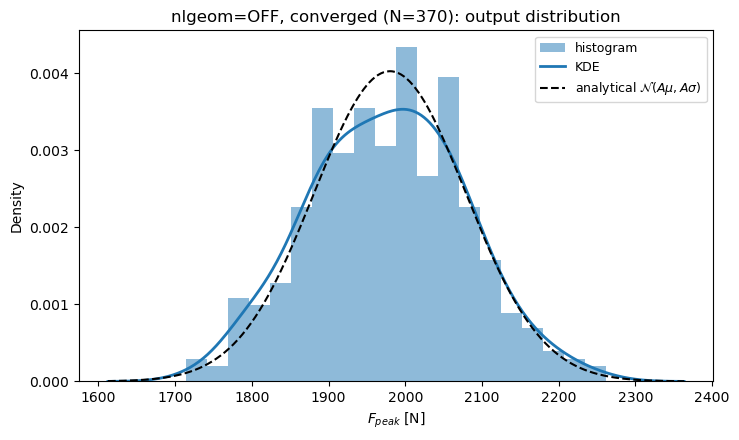

In [13]:
# Reload the converged campaign fresh from disk (rather than reusing whatever was in memory at
# the moment it converged), so this and every later cell reads exactly the N_OFF rows the
# criterion actually accepted.
off_final = load_campaign(SUMMARY_CSV_OFF, n_max=N_OFF)
f_off = off_final["f_peak_recon"]

# A cross-validated KDE of the converged sample (NB2 Part 5's own method, unchanged), evaluated
# on a grid that comfortably spans the data plus a few bandwidths of margin on each side.
h_off = kde_loo_bandwidth(f_off)[0]
x_grid_off = np.linspace(f_off.min() - 3 * h_off, f_off.max() + 3 * h_off, 400)
pdf_kde_off = kde_pdf(x_grid_off, f_off, h_off)

# Overlay three views of the same distribution: the raw histogram, the smoothed KDE, and the
# analytical N(A*mu, A*sigma) this linear map is known to produce exactly (Part 4's own point).
fig, ax = plt.subplots(figsize=(7.5, 4.5))
n_bins = min(20, max(3, len(f_off) // 5))
ax.hist(f_off, bins=n_bins, density=True, color="C0", alpha=0.5, label=f"histogram")
ax.plot(x_grid_off, pdf_kde_off, color="C0", lw=2, label=f"KDE")
ax.plot(x_grid_off, norm.pdf(x_grid_off, analytical_mean, analytical_std), "k--", lw=1.5,
        label=r"analytical $\mathcal{N}(A\mu, A\sigma)$")
ax.set_xlabel("$F_{peak}$ [N]")
ax.set_ylabel("Density")
ax.set_title(f"nlgeom=OFF, converged (N={N_OFF}): output distribution")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


The histogram and the KDE both sit close to the analytical bell curve, as they should: at
`nlgeom=OFF`, $F_{peak}=A\cdot X_T$ is an exact linear map of a Normal input, so the population
this campaign is sampling from really is $\mathcal N(A\mu, A\sigma)$.

NB1 and NB2 already established that simulation+reconstruction error for `nlgeom=OFF` is
negligible, as the reconstructed peak reproduces essentially the exact small-strain prediction to a few
parts in $10^5$, so there is no need to re-litigate that here. What is worth checking is
simply whether this campaign's converged statistics land where the analytical distribution says they should.

In [14]:
# The three summary statistics this notebook tracks throughout: mean, standard deviation, and
# Q5% read as an order statistic (Part 1) -- computed once here on the converged sample and
# compared against the exact analytical values from cell 3.
mean_off, std_off = float(f_off.mean()), float(f_off.std(ddof=1))
q5_off_os = float(np.percentile(f_off, 5))   # the number this notebook REPORTS: an order statistic

print(f"{'quantity':16s}{'analytical':>14s}{'simulated':>14s}{'rel. diff':>12s}")
print("-" * 56)
print(f"{'mean [N]':16s}{analytical_mean:14.2f}{mean_off:14.2f}{100*(mean_off-analytical_mean)/analytical_mean:+11.3f}%")
print(f"{'std [N]':16s}{analytical_std:14.2f}{std_off:14.2f}{100*(std_off-analytical_std)/analytical_std:+11.3f}%")
print(f"{'Q5% [N]':16s}{analytical_q5:14.2f}{q5_off_os:14.2f}{100*(q5_off_os-analytical_q5)/analytical_q5:+11.3f}%")

# Also check the bootstrap CI itself (the last check recorded in checker_off.history, i.e. the
# one that triggered convergence) against the analytical Q5% -- a genuine test of whether the
# interval actually captures the truth, not just of the point estimate.
print(f"\nBootstrap 95% CI on Q5% at N={N_OFF}: "
      f"[{checker_off.history[-1]['ci_low']:.2f}, {checker_off.history[-1]['ci_high']:.2f}] N -- "
      f"{'contains' if checker_off.history[-1]['ci_low'] <= analytical_q5 <= checker_off.history[-1]['ci_high'] else 'does NOT contain'} "
      f"the analytical value.")


quantity            analytical     simulated   rel. diff
--------------------------------------------------------
mean [N]               1980.00       1976.45     -0.179%
std [N]                  99.00        100.93     +1.954%
Q5% [N]                1817.16       1805.83     -0.623%

Bootstrap 95% CI on Q5% at N=370: [1789.08, 1824.93] N -- contains the analytical value.


All three statistics land within about 2% of the analytical prediction, and the bootstrap confidence interval on $Q_{5\%}$ comfortably contains the true analytical value. This gap is ordinary Monte Carlo sampling scatter, as we've already seen in NB2, but this time we also have a quantification of the confidence interval of our quantity of interest.

## Part 5 &ndash; Campaign B: `nlgeom=ON`, converged independently

`nlgeom=ON` gets exactly the same treatment: its own fresh `ConvergenceChecker`, its own call to `run_until_converged`, and, unlike Campaign A, genuinely no closed-form answer to check against afterward. There is no reason to expect it to need the same $N$ as `nlgeom=OFF`: nothing
about the 1% bootstrap criterion ties the two campaigns' sample sizes together, and the two
campaigns are run and converged completely independently below.

In [15]:
RUNS_DIR_ON = Path("../runs/nb03/mc_runs_nlgeom_on")
SUMMARY_CSV_ON = Path("../runs/nb03/monte_carlo_summary_on.csv")

# Same treatment as nlgeom=OFF: a fresh checker with its own seed, run completely independently.
checker_on = ConvergenceChecker(
    "nlgeom=ON", p=0.05, target_rel_half_width=0.01, n_boot=1000,
    rng=np.random.default_rng(102),
)

# Same driver as Campaign A -- nothing here is aware that this campaign has no NB2 predecessor
# or that it may need a different N; it just keeps batching until ITS OWN checker passes.
N_ON = run_until_converged(
    x_pool=x_pool,
    nlgeom="ON",
    runs_dir=RUNS_DIR_ON,
    summary_csv=SUMMARY_CSV_ON,
    target_u1=TARGET_U1,
    stop_check=checker_on.check,
    n_min=N_MIN,
    batch_size=10,
)

print(f"\nnlgeom=ON converged at N={N_ON}.")


[nlgeom=ON] n=  60  Q5%_hat= 1778.92 N  95% CI=[ 1754.59,  1843.22]  rel_half_width=2.491%  (not yet)
[nlgeom=ON] n=  60  (batch just completed) -> not yet converged
[nlgeom=ON] n=  70  Q5%_hat= 1774.63 N  95% CI=[ 1704.29,  1834.47]  rel_half_width=3.668%  (not yet)
[nlgeom=ON] n=  70  (batch just completed) -> not yet converged
[nlgeom=ON] n=  80  Q5%_hat= 1778.92 N  95% CI=[ 1704.29,  1832.32]  rel_half_width=3.599%  (not yet)
[nlgeom=ON] n=  80  (batch just completed) -> not yet converged
[nlgeom=ON] n=  90  Q5%_hat= 1783.95 N  95% CI=[ 1728.13,  1834.47]  rel_half_width=2.980%  (not yet)
[nlgeom=ON] n=  90  (batch just completed) -> not yet converged
[nlgeom=ON] n= 100  Q5%_hat= 1789.07 N  95% CI=[ 1754.62,  1837.10]  rel_half_width=2.305%  (not yet)
[nlgeom=ON] n= 100  (batch just completed) -> not yet converged
[nlgeom=ON] n= 110  Q5%_hat= 1787.49 N  95% CI=[ 1757.27,  1835.01]  rel_half_width=2.174%  (not yet)
[nlgeom=ON] n= 110  (batch just completed) -> not yet converged
[nlg

### Watching it converge

Same two panels as for `nlgeom=OFF`: the running $\widehat{Q}_{5\%}$ with its 95% band, and the
relative half-width shrinking toward (and through) the 1% target.

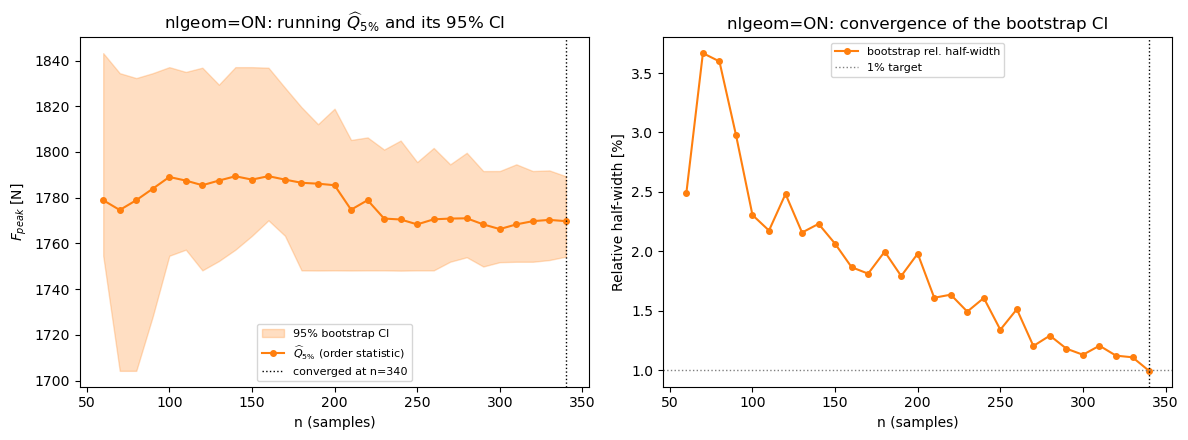

In [16]:
plot_convergence(checker_on, "C1", "nlgeom=ON")


Nothing ties the two campaigns' own 1%-target sample sizes together: `nlgeom=OFF` needed
$N=370$ against `nlgeom=ON`'s $N=340$, a gap well inside the batch-to-batch wobble either
trajectory shows on its own, so it is not evidence that one campaign is intrinsically harder to
converge than the other. `nlgeom=ON`'s own trajectory happens to descend more directly than `nlgeom=OFF`'s did, with no
close near-miss the way `nlgeom=OFF` had just below the target; that difference is ordinary
run-to-run variation in the bootstrap, not a systematic property of either element formulation.

### Campaign cost

The same reporting as for `nlgeom=OFF`, for comparison.

In [17]:
# Same reporting as for nlgeom=OFF, straight off the converged campaign's own summary.csv.
run_seconds_on = load_campaign(SUMMARY_CSV_ON, n_max=N_ON)["run_seconds"]
print(f"--- nlgeom=ON campaign cost ({len(run_seconds_on)} completed runs) ---")
print(f"Total wall-clock time (sum of every run's own solve time): {run_seconds_on.sum():8.0f} s "
      f"({run_seconds_on.sum() / 3600:.2f} h)")
print(f"Per-run solve time:  mean={run_seconds_on.mean():.1f}s, std={run_seconds_on.std(ddof=1):.1f}s, "
      f"min={run_seconds_on.min():.1f}s, max={run_seconds_on.max():.1f}s")
print(f"\nFor comparison, nlgeom=OFF: {run_seconds_off.sum():.0f} s total over {len(run_seconds_off)} runs.")


--- nlgeom=ON campaign cost (340 completed runs) ---
Total wall-clock time (sum of every run's own solve time):     6928 s (1.92 h)
Per-run solve time:  mean=20.4s, std=2.1s, min=18.9s, max=29.4s

For comparison, nlgeom=OFF: 7651 s total over 370 runs.


`nlgeom=OFF` ended up needing more samples than `nlgeom=ON` this time (370 against 340), so
its total cost is the larger one, even though the two campaigns' own per-run solve times are
indistinguishable: there is no per-run overhead here that `nlgeom=ON`'s nonlinear formulation
adds, only the same modest, seed-dependent gap in required sample count already seen above.


### Step 1 &ndash; look at the data first: the pointwise check

Before any statistic, the same move NB2 made in its own Part 5, Step 1: plot every run's own
output against the input that produced it, and name in advance what would count as a finding.
For `nlgeom=ON` there is no closed-form line to test the map against, but a few things are
still expected: an **offset** from the small-strain reference $A\cdot X_T$ (NB1 already explains
why nlgeom=ON should sit below it), and a gentle, **smooth trend** with $X_T$. What is *not*
expected is anything **discontinuous**. A jump would mean something structurally different happened between two very similar samples, which a mean or a percentile has no way to flag.

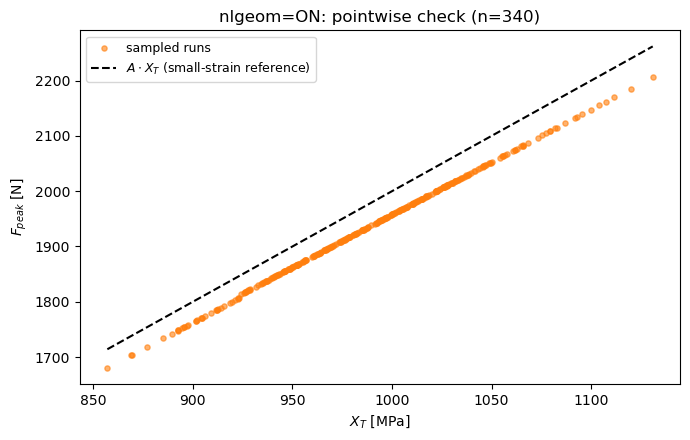

Largest single step in the reconstructed peak, X_T=923.2088 -> 924.1077 MPa:
  F_peak_recon: 1806.587 N -> 1813.301 N  (jump of +6.714 N)


In [18]:
# Reload the converged ON campaign, and plot every run's own (X_T, F_peak_recon) pair against
# the small-strain reference A*X_T -- the same "look at the data first" move NB2 made before
# trusting any summary statistic.
on_final = load_campaign(SUMMARY_CSV_ON, n_max=N_ON)
x_t_on, f_on = on_final["x_t"], on_final["f_peak_recon"]

x_line = np.array([x_t_on.min(), x_t_on.max()])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x_t_on, f_on, s=14, alpha=0.6, color="C1", label="sampled runs")
ax.plot(x_line, A * x_line, "k--", lw=1.5, label=r"$A\cdot X_T$ (small-strain reference)")
ax.set_xlabel("$X_T$ [MPa]")
ax.set_ylabel("$F_{peak}$ [N]")
ax.set_title(f"nlgeom=ON: pointwise check (n={N_ON})")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# The two neighbouring samples straddling the small step this plot will turn out to show (found
# by locating the largest single jump in the residual against A*X_T, sorted by X_T -- not
# hard-coded indices, so this keeps working if the campaign is ever extended or re-run).
order = np.argsort(x_t_on)
xs, fs = x_t_on[order], f_on[order]
resid_sorted = (fs - A * xs) / (A * xs)
k = int(np.argmax(np.diff(resid_sorted)))
print(f"Largest single step in the reconstructed peak, X_T={xs[k]:.4f} -> {xs[k+1]:.4f} MPa:")
print(f"  F_peak_recon: {fs[k]:.3f} N -> {fs[k+1]:.3f} N  (jump of {fs[k+1]-fs[k]:+.3f} N)")


At full-figure scale the cloud looks like one smooth, linear trend a little below the dashed $A\cdot X_T$ line, as expected. However, looking more closely at the data, we can see a small jump in $F_{peak}$ at approximately $X_T=925$ MPa. Nothing in the underlying physics is expected to change here, so this needs explaining.

### Where the step comes from

`reconstruct_peak` (NB1's method, `scripts/peak_reconstruction.py`) splits a run's recorded
history at `init_idx = argmax(HSNFTCRT >= 1.0)`, the first recorded increment where the failure
criterion reaches 1, and fits a straight line through the two increments just before it (the
"elastic" chord) and another through the two just after (the "softening" chord); the
reconstructed peak is where those two chords cross.

Every run in this campaign records the **same** increment sequence in displacement
($u_1 = 0,\ 0.04,\ 0.08,\ 0.14,\ 0.23,\ 0.365,\dots$ mm, at `U1=4.0`), because, given the simplicity of the single-element model, the solver converges to the same displacement increments every time (with a different reaction force depending on the value of $X_T$). However, the displacement at which damage actually **initiates** grows steadily with $X_T$ (a stronger fiber survives to a larger strain, hence a larger $u_1$, before failing). So there has to be some $X_T$ where the initiation displacement crosses from landing just before one particular recorded increment to just after it. Exactly there, `init_idx` steps from one integer to the next, and the two chords are suddenly fitted through a **structurally different pair of increments** than they were one sample earlier. The cell below shows this directly.

init_idx switches between sample 128 (X_T=923.2088 MPa, init_idx=4) and sample 267 (X_T=924.1077 MPa, init_idx=5)


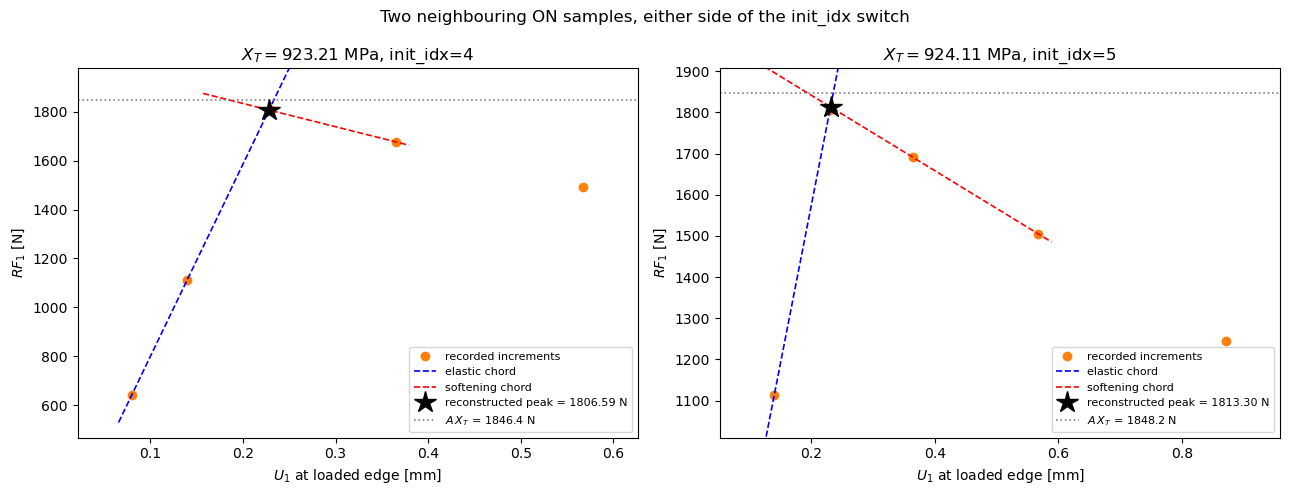


Sample 128:  reconstructed peak = 1806.587 N
   k     u1 [mm]      RF1 [N]   HSNFTCRT   role
   2     0.08000      641.880     0.1228   elastic
   3     0.14000     1113.329     0.3738   elastic
   4     0.23000     1804.903     1.0000   softening  <-- init_idx
   5     0.36500     1676.483     1.0000   softening
   6     0.56750     1492.858     1.0000   

Sample 267:  reconstructed peak = 1813.301 N
   k     u1 [mm]      RF1 [N]   HSNFTCRT   role
   3     0.14000     1113.329     0.3731   elastic
   4     0.23000     1804.933     0.9981   elastic
   5     0.36500     1690.596     1.0000   softening  <-- init_idx
   6     0.56750     1505.043     1.0000   softening
   7     0.87125     1245.504     1.0000   


In [19]:
# Locate the two ON samples that straddle the step by computing init_idx (the increment where
# HSNFTCRT first reaches 1.0, see the markdown above) for every run in the converged campaign,
# then finding where that integer changes as X_T increases -- not hard-coded, so this keeps
# working if the campaign were ever extended or re-run.
init_idx_on = []
for i in range(N_ON):
    d = json.load(open(RUNS_DIR_ON / f"run_{i:03d}.json"))
    init_idx_on.append(int(np.argmax(np.array(d["hsn_ft"]) >= 1.0)))
init_idx_on = np.array(init_idx_on)

order = np.argsort(x_t_on)                            # every run, ordered by its own X_T
init_sorted = init_idx_on[order]
switch = int(np.argmax(np.diff(init_sorted) != 0))    # first place init_idx changes, in X_T order
i_lo, i_hi = order[switch], order[switch + 1]          # the ORIGINAL sample indices either side

print(f"init_idx switches between sample {i_lo} (X_T={x_t_on[i_lo]:.4f} MPa, init_idx={init_idx_on[i_lo]}) "
      f"and sample {i_hi} (X_T={x_t_on[i_hi]:.4f} MPa, init_idx={init_idx_on[i_hi]})")

# For each of the two samples, re-fit the exact same elastic/softening chords reconstruct_peak
# uses internally, then plot the recorded increments, both chords, and their crossing point
# zoomed in on the few increments around init_idx -- so the "different pair of increments"
# explanation in the markdown above is visible directly, not just asserted.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tables = []
for ax, i in zip(axes, (i_lo, i_hi)):
    d = json.load(open(RUNS_DIR_ON / f"run_{i:03d}.json"))
    u1, rf1, hsn = np.array(d["u1"]), np.array(d["rf1"]), np.array(d["hsn_ft"])
    init_idx = int(np.argmax(hsn >= 1.0))
    elastic_idx = [init_idx - 2, init_idx - 1]     # the two increments BEFORE init_idx -- reconstruct_peak's "elastic" chord
    softening_idx = [init_idx, init_idx + 1]       # init_idx and the one after -- the "softening" chord
    elastic = np.polyfit(u1[elastic_idx], rf1[elastic_idx], 1)
    softening = np.polyfit(u1[softening_idx], rf1[softening_idx], 1)
    u1_peak, f_peak = reconstruct_peak(u1, rf1, hsn)   # NB1's own method, applied here exactly as it is inside mc_campaign

    # Draw each chord a little beyond its own two anchor points (25% of the elastic-softening
    # span) so both lines visibly extend to, and cross at, the reconstructed peak.
    span = u1[softening_idx[1]] - u1[elastic_idx[0]]
    u_e = np.array([u1[elastic_idx[0]] - 0.05 * span, u1_peak + 0.25 * span])
    u_s = np.array([u1_peak - 0.25 * span, u1[softening_idx[1]] + 0.05 * span])
    ax.plot(u1, rf1, "o", ms=6, color="C1", label="recorded increments")
    ax.plot(u_e, np.polyval(elastic, u_e), "b--", lw=1.2, label="elastic chord")
    ax.plot(u_s, np.polyval(softening, u_s), "r--", lw=1.2, label="softening chord")
    ax.plot(u1_peak, f_peak, "k*", ms=16, zorder=5, label=f"reconstructed peak = {f_peak:.2f} N")
    ax.axhline(A * d["x_t"], color="gray", ls=":", lw=1.2, label=f"$A\,X_T$ = {A * d['x_t']:.1f} N")

    # Zoom the axes to just the handful of increments around init_idx, padded a little on every
    # side, so the two chords and their crossing point fill the panel rather than being lost in
    # the full force-displacement curve's much larger range.
    k0, k1 = max(0, init_idx - 2), min(len(u1) - 1, init_idx + 2)
    pad_x = 0.12 * (u1[k1] - u1[k0])
    ax.set_xlim(u1[k0] - pad_x, u1[k1] + pad_x)
    band = rf1[k0:k1 + 1]
    pad_y = 0.15 * (band.max() - band.min())
    ax.set_ylim(band.min() - pad_y, band.max() + pad_y)
    ax.set_xlabel("$U_1$ at loaded edge [mm]")
    ax.set_ylabel("$RF_1$ [N]")
    ax.set_title(f"$X_T={d['x_t']:.2f}$ MPa, init_idx={init_idx}")
    ax.legend(fontsize=8, loc="lower right")

    # Record every increment shown in this panel (with its role: elastic/softening/neither) for
    # the printed table below, so the plot and the numbers it is based on can be read side by side.
    table = []
    for k in range(k0, k1 + 1):
        role = "elastic" if k in elastic_idx else ("softening" if k in softening_idx else "")
        table.append((k, u1[k], rf1[k], hsn[k], role))
    tables.append((i, init_idx, table, f_peak))

fig.suptitle("Two neighbouring ON samples, either side of the init_idx switch")
fig.tight_layout()
plt.show()

for i, init_idx, table, f_peak in tables:
    print(f"\nSample {i}:  reconstructed peak = {f_peak:.3f} N")
    print(f"{'k':>4}{'u1 [mm]':>12}{'RF1 [N]':>13}{'HSNFTCRT':>11}   role")
    for k, u, f, h, role in table:
        flag = "  <-- init_idx" if k == init_idx else ""
        print(f"{k:>4}{u:>12.5f}{f:>13.3f}{h:>11.4f}   {role}{flag}")


At $u_1=0.23$ mm, the sample at $X_T=923.21$ MPa records `HSNFTCRT = 1.0000`. The
criterion has already saturated, so this increment anchors the **softening** chord. The sample
at $X_T=924.11$ MPa records `HSNFTCRT = 0.9981` at the very same displacement, not quite
there yet, so this increment anchors the **elastic** chord instead. Both chords are therefore
fitted through a different pair of points on either side of this 0.9 MPa gap, and the two
resulting crossing points (1806.59 N and 1813.30 N) differ by a 6.7 N step.

There is **no action to take here**: both reconstructions are legitimate applications of NB1's
method, the step is small (0.37% of the peak force), and the entire lower tail this campaign
cares about &mdash; including $Q_{5\%}\approx 1770$ N, well below the $\approx1810$ N where the
step sits &mdash; falls on one side of it. But it *is* a genuine numerical artifact of the
post-processing, not physics, and it is the same order of magnitude as quantities this notebook
is trying to resolve to 1% precision. **The general lesson:** it is not enough to trust that a numerical model is correct in the aggregate. Its post-processing has to be checked for robustness across the *whole* sampled range too, because any numerical
artifact, however small, propagates straight into the output distribution a Monte Carlo campaign builds on top of it.

### The converged output distribution, `nlgeom=ON` vs. `nlgeom=OFF`

There is no analytical curve to overlay here, which is the entire point of this campaign.
Instead, the cell below overlays the converged `nlgeom=ON` histogram and KDE with the **KDE of
the converged `nlgeom=OFF` sample** from Part 4, so the two empirically-determined distributions
can be compared directly.

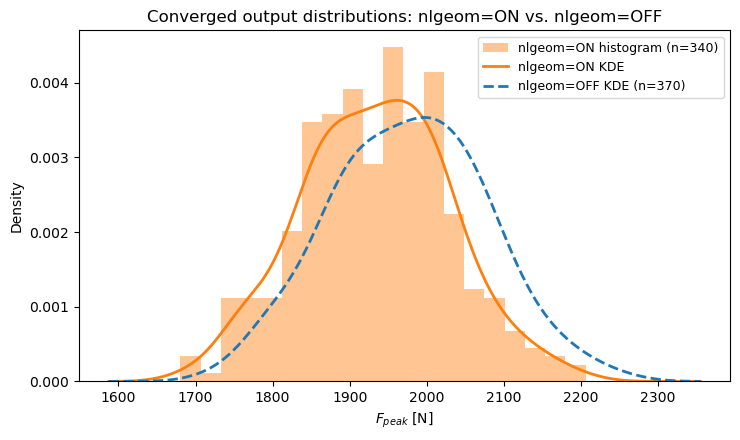

In [20]:
# Fit ON's own KDE the same way OFF's was fit in Part 4, and evaluate OFF's KDE (already fit,
# `h_off`/`pdf_kde_off` are still in memory) over a grid wide enough to cover both campaigns'
# ranges, so the two densities can be drawn on one shared x-axis.
h_on = kde_loo_bandwidth(f_on)[0]
x_grid_on = np.linspace(min(f_on.min(), f_off.min()) - 3 * h_on,
                         max(f_on.max(), f_off.max()) + 3 * h_on, 400)
pdf_kde_on = kde_pdf(x_grid_on, f_on, h_on)
pdf_kde_off_over = kde_pdf(x_grid_on, f_off, h_off)   # OFF's own converged KDE, over ON's grid

fig, ax = plt.subplots(figsize=(7.5, 4.5))
n_bins_on = min(20, max(3, len(f_on) // 5))
ax.hist(f_on, bins=n_bins_on, density=True, color="C1", alpha=0.45, label=f"nlgeom=ON histogram (n={N_ON})")
ax.plot(x_grid_on, pdf_kde_on, color="C1", lw=2, label=f"nlgeom=ON KDE")
ax.plot(x_grid_on, pdf_kde_off_over, color="C0", lw=2, ls="--",
        label=f"nlgeom=OFF KDE (n={N_OFF})")
ax.set_xlabel("$F_{peak}$ [N]")
ax.set_ylabel("Density")
ax.set_title("Converged output distributions: nlgeom=ON vs. nlgeom=OFF")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


The `nlgeom=ON` distribution sits visibly to the left of `nlgeom=OFF`'s, with a similar
spread and shape, looking like a shift rather than a reshaping. The table below reads mean, standard deviation, and $Q_{5\%}$ straight off each campaign's own converged sample, alongside the relative shift of each quantity from OFF to ON.


In [21]:
# Same three statistics as Part 4's own table (mean, std, Q5% as an order statistic), computed
# on ON's converged sample, then compared directly to OFF's own values already in memory.
mean_on, std_on = float(f_on.mean()), float(f_on.std(ddof=1))
q5_on_os = float(np.percentile(f_on, 5))


def rel_shift(on_val, off_val):
    return (on_val - off_val) / off_val


print(f"{'quantity':22s}{'nlgeom=OFF':>14s}{'nlgeom=ON':>14s}{'relative shift':>16s}")
print("-" * 66)
print(f"{'mean [N]':22s}{mean_off:14.2f}{mean_on:14.2f}{rel_shift(mean_on, mean_off):16.3%}")
print(f"{'std [N]':22s}{std_off:14.2f}{std_on:14.2f}{rel_shift(std_on, std_off):16.3%}")
print(f"{'Q5% (order stat) [N]':22s}{q5_off_os:14.2f}{q5_on_os:14.2f}{rel_shift(q5_on_os, q5_off_os):16.3%}")
print(f"\nN_OFF={N_OFF}, N_ON={N_ON}")


quantity                  nlgeom=OFF     nlgeom=ON  relative shift
------------------------------------------------------------------
mean [N]                     1976.45       1933.81         -2.157%
std [N]                       100.93         96.11         -4.778%
Q5% (order stat) [N]         1805.83       1769.75         -1.998%

N_OFF=370, N_ON=340


**The mean and the 5th percentile shift by essentially the same relative amount** (both
close to $-2\%$), while the standard deviation shifts somewhat more (about $-5\%$): turning
on geometric nonlinearity moves the whole distribution down by a broadly consistent fraction and
narrows its spread somewhat, but there is no evidence here that it reshapes the lower tail
disproportionately relative to the center. As NB1 already established: `nlgeom=ON` measures
strain logarithmically ($\ln(1+U_1/L)$, smaller than the small-strain value for the same $U_1$)
and carries stress on the current, Poisson-contracted cross-section rather than the original
one. Both effects push the reconstructed peak down relative to $A\cdot X_T$, and both
grow smoothly with the sampled $X_T$, consistent with the shift landing on mean and $Q_{5\%}$
alike rather than distorting one relative to the other.


### The comparison, with confidence intervals

A shift in the point estimates is not yet evidence of a real effect unless it is checked against
how uncertain each campaign's own estimate is. The cell below reuses Part 1's own
`bootstrap_ci` to build a 95% confidence interval on the **mean** and on $Q_{5\%}$ of each
converged campaign ($B=1000$, each with its own seeded generator), then plots all four estimates
&ndash; both statistics, both campaigns &ndash; on one axis, in the same units (N), so their
intervals can be compared directly.


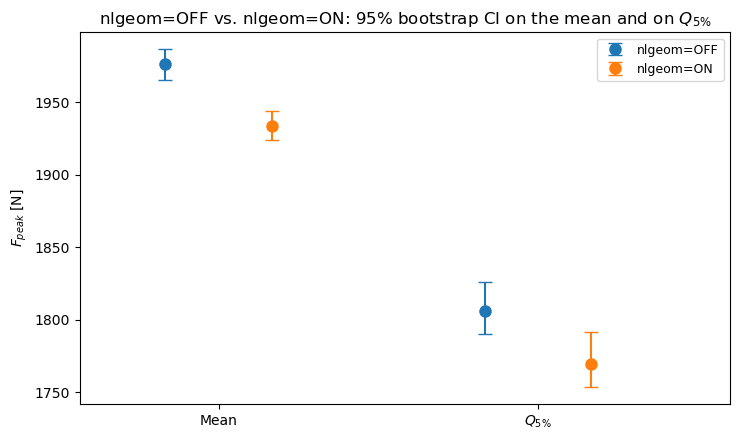

Mean:  OFF 95% CI=[1965.35, 1986.72]   ON 95% CI=[1924.02, 1944.35]
Q5%:   OFF 95% CI=[1789.86, 1826.21]   ON 95% CI=[1753.57, 1791.57]
Q5% interval overlap: 1.71 N


In [22]:
# Reuse Part 1's own bootstrap_ci for two different statistics: the mean (mean_fn) and the
# order-statistic Q5% (q5_fn, already defined in Part 1 -- not redefined here).
mean_fn = lambda a, axis: a.mean(axis=axis)

# One bootstrap CI per (campaign, statistic) combination -- four in total -- each with its own
# seeded generator so OFF's and ON's draws cannot influence one another.
boot_mean_off = bootstrap_ci(f_off, mean_fn, rng=np.random.default_rng(201))
boot_q5_off = bootstrap_ci(f_off, q5_fn, rng=np.random.default_rng(201))
boot_mean_on = bootstrap_ci(f_on, mean_fn, rng=np.random.default_rng(202))
boot_q5_on = bootstrap_ci(f_on, q5_fn, rng=np.random.default_rng(202))

# All four estimates are forces in N and of comparable magnitude, so they can share one axis:
# two x-positions (mean, Q5%), each holding an OFF marker next to an ON marker.
results = {
    ("Mean", "OFF"): (0, boot_mean_off, "C0"), ("Mean", "ON"): (1, boot_mean_on, "C1"),
    ("$Q_{5\%}$", "OFF"): (3, boot_q5_off, "C0"), ("$Q_{5\%}$", "ON"): (4, boot_q5_on, "C1"),
}

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for (label, campaign), (x, res, color) in results.items():
    ax.errorbar([x], [res["estimate"]],
                yerr=[[res["estimate"] - res["ci_low"]], [res["ci_high"] - res["estimate"]]],
                fmt="o", color=color, ms=8, capsize=5,
                label=f"nlgeom={campaign}" if label == "Mean" else None)  # one legend entry per campaign, not per point

ax.set_xticks([0.5, 3.5])
ax.set_xticklabels(["Mean", "$Q_{5\%}$"])
ax.set_xlim(-0.8, 5.3)
ax.set_ylabel("$F_{peak}$ [N]")
ax.set_title("nlgeom=OFF vs. nlgeom=ON: 95% bootstrap CI on the mean and on $Q_{5\%}$")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# The overlap between OFF's and ON's Q5% intervals, computed here rather than hard-coded, so it
# stays correct if either campaign is ever extended or re-run. A positive number is how much the
# two intervals overlap; a negative number is the gap between them.
q5_overlap = min(boot_q5_off["ci_high"], boot_q5_on["ci_high"]) - max(boot_q5_off["ci_low"], boot_q5_on["ci_low"])

print(f"Mean:  OFF 95% CI=[{boot_mean_off['ci_low']:.2f}, {boot_mean_off['ci_high']:.2f}]   "
      f"ON 95% CI=[{boot_mean_on['ci_low']:.2f}, {boot_mean_on['ci_high']:.2f}]")
print(f"Q5%:   OFF 95% CI=[{boot_q5_off['ci_low']:.2f}, {boot_q5_off['ci_high']:.2f}]   "
      f"ON 95% CI=[{boot_q5_on['ci_low']:.2f}, {boot_q5_on['ci_high']:.2f}]")
print(f"Q5% interval overlap: {q5_overlap:.2f} N" if q5_overlap > 0 else
      f"Q5% intervals do not overlap (gap of {-q5_overlap:.2f} N)")


The mean intervals are clearly separated, with no overlap at all. The $Q_{5\%}$ intervals, by contrast, only just touch, overlapping by about 1.7 N on intervals roughly 37 N wide. Comparing two separate intervals for overlap is a conservative check, meaning that even with some overlap the two estimates can still be considered significantly different. To quantify that, we would need to bootstrap the *difference* of the two campaigns' own estimates. However, this is beyond the scope of this notebook, and we defer that to a later notebook.

## Conclusion

This notebook took away the one shortcut NB2 relied on, a closed-form answer to size $N$
against, and replaced it with tools that do not need one.

**What this notebook established:**

- **The bootstrap** turns a finite sample into a confidence interval for an estimator built from
  it, using only resampling *with replacement* &ndash; no distributional assumption, and no need
  to repeat the underlying (Abaqus) experiment.
- **Bootstrapping a percentile produces a visibly discrete distribution** at a few hundred
  samples, because a resample's own order statistics can only ever take values already in the
  original sample. This is not a defect: [Hall & Martin (1989)](https://doi.org/10.1016/0167-7152(89)90121-3) showed that the
  percentile bootstrap interval for a quantile *is* the classical order-statistic interval, so
  the lattice seen in the histogram is the same finite-sample mechanism that interval has always had.
- **The number of bootstrap resamples, $B$, was sized empirically** by running the
  bootstrap at a range of $B$ with independent seeds and watching where the reported half-width
  stops depending on the seed. The scatter falls to a floor (about 0.07 percentage points)
  rather than to zero, set by that same discreteness, and is essentially settled by $B=1000$
  &ndash; the value adopted, and the same one [Catalanotti (2022)](https://doi.org/10.1016/j.compositesa.2022.107238) uses.
- **A genuine convergence criterion**: stop the first time a 1% relative bootstrap   half-width on the order-statistic $\widehat{Q_{5\%}}$ is reached, guarded by a minimum sample size ($n_{\min}=60$) below which no such interval can exist at all.
- **`nlgeom=OFF`, converged as if no closed form existed**, needed $N=370$, more than NB2's $N=280$, and its converged statistics matched the analytical $\mathcal N(A\mu, A\sigma)$ within ordinary Monte Carlo sampling scatter (all three within about 2%).
- **`nlgeom=ON`, converged independently**, needed its own $N=340$. Nothing ties the two campaigns' required sample sizes together, and this notebook's central design choice (converge each campaign on its own criterion, separately) exists specifically to let that show up rather than be hidden by a shared, arbitrary sample size.
- **`nlgeom=ON`'s own pointwise check** surfaced a small (0.37%), fully explained numerical artifact in the
  peak-reconstruction method itself: a step where the increment anchoring the reconstruction
  switches sides as $X_T$ crosses a threshold. Harmless here (the whole lower tail sits on one
  side of it, and the `nlgeom=OFF` control shows no such step under the identical switch), but a
  reminder that a model's post-processing, not just the model itself, needs checking for
  robustness across the whole sampled range before its output feeds a Monte Carlo campaign.
- **The converged distributions and statistics** showed `nlgeom=ON` shifting the whole
  distribution of $F_{peak}$ down relative to `nlgeom=OFF`: mean and $Q_{5\%}$ both by about 2%,
  standard deviation by about 5%. The mean's 95% confidence intervals are clearly separated
  between the two campaigns; the $Q_{5\%}$ intervals only just touch, which is not evidence
  against a real difference, only a reminder that comparing two separate intervals is a
  conservative test. The shift is traced to NB1's logarithmic-strain and Poisson-contracted-cross-section effects.

**Where this goes next.** Both campaigns here still treat $X_T$ as the *only* uncertain input, still Normal, still feeding a single-element model with a single failure mode. The natural next steps are a physically better-motivated distribution for fiber strength (Weibull, via weakest-link theory) and, eventually, a model with more than one uncertain input and more than one element, where a vanilla Monte Carlo campaign of the size these first three notebooks needed becomes computationally unaffordable and variance-reduction or surrogate-modeling techniques stop being optional.